## NEP_MSD

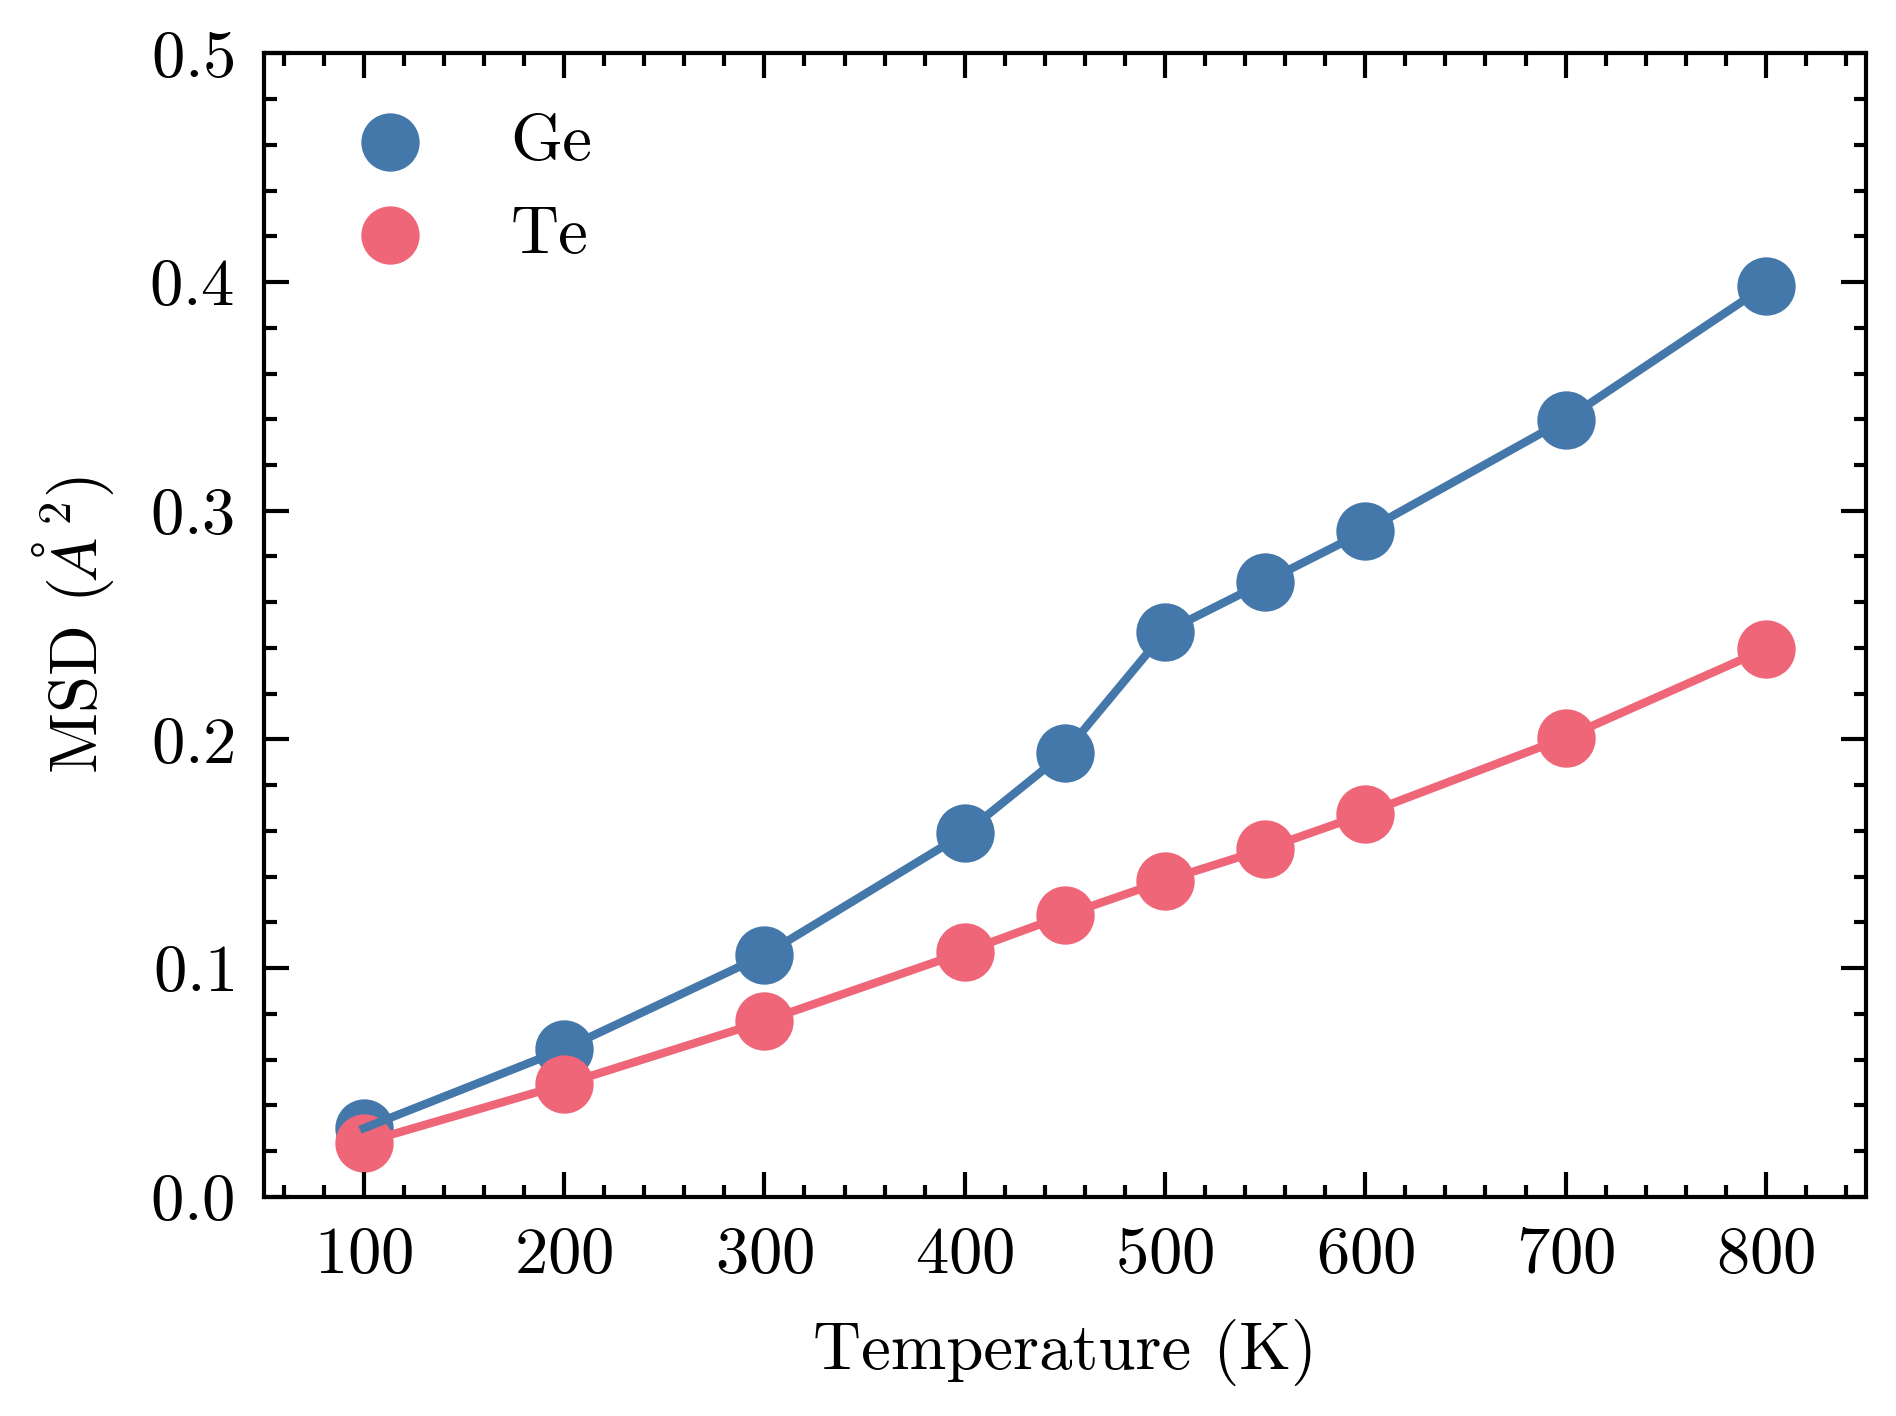

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import seaborn as sns

plt.style.use(['science','ieee','no-latex','bright'])
colors = ["#1C3C63", "#F0686C"]

# Ge和Te数据
Ge = np.array([
    [100, 0.0102169, 0.010274 , 0.00953308],
    [200, 0.0219001, 0.021931 , 0.0207941],
    [300, 0.035796 , 0.0358357, 0.0341418],
    [400, 0.0536073, 0.0537079, 0.0516338],
    [450, 0.0652958, 0.0654039, 0.0635422],
    [500, 0.0820974, 0.0821511, 0.0826943],
    [550, 0.0893657, 0.0893743, 0.0901812],
    [600, 0.0968025, 0.0967031, 0.0975777],
    [700, 0.11307  , 0.113074 , 0.113682],
    [800, 0.13306  , 0.133003 , 0.132345]
])
Te = np.array([
    [100, 0.007965 , 0.0080154, 0.00776613],
    [200, 0.0164779, 0.01641  , 0.0163721],
    [300, 0.0255708, 0.0255545, 0.0257301],
    [400, 0.035763 , 0.0357294, 0.0356324],
    [450, 0.0411504, 0.0410918, 0.0409399],
    [500, 0.0459366, 0.0459071, 0.04648],
    [550, 0.0504445, 0.0505432, 0.0511684],
    [600, 0.0555867, 0.0555113, 0.0564662],
    [700, 0.0667233, 0.0667493, 0.0673594],
    [800, 0.0799278, 0.0799864, 0.079661]
])

# 创建DataFrame并计算MSD总和
msd_Ge = pd.DataFrame(Ge, columns=["Temp", "x", "y", "z"])
msd_Te = pd.DataFrame(Te, columns=["Temp", "x", "y", "z"])
msd_Ge["MSD_total"] = msd_Ge["x"] + msd_Ge["y"] + msd_Ge["z"]
msd_Te["MSD_total"] = msd_Te["x"] + msd_Te["y"] + msd_Te["z"]

# 绘制散点图
plt.figure()
plt.scatter(msd_Ge["Temp"], msd_Ge["MSD_total"], label='Ge')
plt.plot(msd_Ge["Temp"], msd_Ge["MSD_total"])
plt.scatter(msd_Te["Temp"], msd_Te["MSD_total"], label='Te')
plt.plot(msd_Te["Temp"], msd_Te["MSD_total"])

plt.xlabel('Temperature (K)')
plt.ylabel('MSD ($Å^2$)')
plt.xlim(50, 850)
plt.ylim(0, 0.5)
plt.legend()
plt.tight_layout()
plt.savefig("msd.png", bbox_inches='tight')

## Ovito_MSD

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*OVITO.*PyPI')

import ovito._extensions.pyscript
from ovito.io import import_file, export_file
from ovito.modifiers import CalculateDisplacementsModifier, SelectTypeModifier, DeleteSelectedModifier
import numpy as np
import matplotlib.pyplot as plt

def setup_pipeline(atom_type, ref_file, traj_file):
    # 导入轨迹文件
    pipeline = import_file(traj_file)

    # 导入参考配置
    reference_pipeline = import_file(ref_file)
    
    # 设置参考配置
    mod = CalculateDisplacementsModifier()
    mod.reference = reference_pipeline.source
    pipeline.modifiers.append(mod)

    # 选择非目标原子并删除
    select_other = SelectTypeModifier(property="Particle Type", types={atom_type})
    pipeline.modifiers.append(select_other)
    pipeline.modifiers.append(DeleteSelectedModifier())

    return pipeline

def calculate_msd(frame, data, attribute_name):
    displacement_magnitudes = data.particles["Displacement Magnitude"]
    msd = np.sum(displacement_magnitudes ** 2) / len(displacement_magnitudes)
    data.attributes[attribute_name] = msd
    data.attributes["Timestep"] = frame  # 添加时间步长信息

def main():
    # 配置文件路径
    ref_file = './model.xyz'
    traj_file = './dump.xyz'

    # 计算Ge原子的MSD
    pipeline_ge = setup_pipeline('Te', ref_file, traj_file)
    pipeline_ge.modifiers.append(lambda frame, data: calculate_msd(frame, data, "MSD_Ge"))
    export_file(pipeline_ge, "output_ge.txt", format="txt/attr", columns=["Timestep", "MSD_Ge"], multiple_frames=True, start_frame=1)

    # 计算Te原子的MSD
    pipeline_te = setup_pipeline('Ge', ref_file, traj_file)
    pipeline_te.modifiers.append(lambda frame, data: calculate_msd(frame, data, "MSD_Te"))
    export_file(pipeline_te, "output_te.txt", format="txt/attr", columns=["Timestep", "MSD_Te"], multiple_frames=True, start_frame=1)

    # 读取数据
    ge_data = np.loadtxt("output_ge.txt", skiprows=1)
    te_data = np.loadtxt("output_te.txt", skiprows=1)

    # 分别获取时间步长和MSD数据
    timesteps_ge, msd_ge = ge_data[:, 0], ge_data[:, 1]
    timesteps_te, msd_te = te_data[:, 0], te_data[:, 1]

    # 绘制MSD随时间的演化图
    plt.figure()
    plt.plot(timesteps_ge, msd_ge, label='Ge MSD')
    plt.plot(timesteps_te, msd_te, label='Te MSD')
    plt.xlabel('Timestep')
    plt.ylabel('MSD')
    plt.legend()
    plt.title('MSD vs Timestep for Ge and Te atoms')
    plt.show()

if __name__ == "__main__":
    main()